In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../fortran"))  # make sure we load the right .so

import cletkf_wloc as mod
print("Loaded:", mod.__file__)
print("Exported names:")
print([n for n in dir(mod) if not n.startswith("_")])

Loaded: /nfsmounts/demerzel/datos/jorge.gacitua/wrf_python_Assimilation/fortran/cletkf_wloc.cpython-38-x86_64-linux-gnu.so
Exported names:
['common_da', 'common_letkf', 'common_mtx', 'common_tools', 'daxpy', 'dcopy', 'ddot', 'dgemm', 'do_recursion', 'dspdi', 'dspfa', 'dswap', 'gen_rand32', 'gen_rand64', 'gen_rand_all', 'genrand_res53', 'idamax', 'init_gen_rand', 'lsame', 'lshift128', 'mod_sfmt', 'period_certification', 'pythag', 'rs', 'rshift128', 'tql1', 'tql2', 'tred1', 'tred2', 'xerbla']


In [ ]:
from netCDF4 import Dataset
dataset=Dataset("/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/20231216120000/001/wrfout_d01_2023-12-16_19:00:00")

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "../fortran"))
from cletkf_wloc      import common_da        as cda

# Load the cross-section data
data = np.load("../data/ensemble_cross_sections.npz")
#data = np.load("/home/jorge.gacitua/datosdemerzel/CrossSection_Assimilation/ensemble_cross_sections.npz")
cross_sections = data["cross_sections"]


# Get relevant dimensions
nx, ny, nz, nbv, nvar = cross_sections.shape  # (lon, lat, levels, members, variables)
print("cross_sections shape:", cross_sections.shape)
dbz_idx = 0#nvar - 1  # If DBZ is the last variable

dbz_data_all = np.zeros((nx,nz,nbv))
for i in range(nx):
    for j in range(nz):
        for k in range(nbv):
            qg = cross_sections[i, 0, j, k, 0]
            qr = cross_sections[i, 0, j, k, 1]
            qs = cross_sections[i, 0, j, k, 2]
            tt = cross_sections[i, 0, j, k, 3]
            pp = cross_sections[i, 0, j, k, 4]
            dbz_data_all[i,j,k] = cda.calc_ref( qr , qs , qg , tt , pp )


cross_sections shape: (77, 1, 100, 30, 8)


In [7]:
print(np.nanmin(cross_sections[:,:,:,:,0]))
print(np.nanmax(cross_sections[:,:,:,:,0]))

print(np.nanmin(cross_sections[:,:,:,:,1]))
print(np.nanmax(cross_sections[:,:,:,:,1]))

print(np.nanmin(cross_sections[:,:,:,:,2]))
print(np.nanmax(cross_sections[:,:,:,:,2]))

print(np.nanmin(cross_sections[:,:,:,:,3]))
print(np.nanmax(cross_sections[:,:,:,:,3]))

print(np.nanmin(cross_sections[:,:,:,:,4]))
print(np.nanmax(cross_sections[:,:,:,:,4]))

0.0
0.013230927288532257
0.0
0.010754171758890152
0.0
0.004650686401873827
187.62335205078125
306.80731201171875
10.949874877929688
968.8863525390625


In [63]:
print(np.nanmin(cross_sections[:,:,:,:,0]))
print(np.nanmax(cross_sections[:,:,:,:,0]))

print(np.nanmin(cross_sections[:,:,:,:,1]))
print(np.nanmax(cross_sections[:,:,:,:,1]))

print(np.nanmin(cross_sections[:,:,:,:,2]))
print(np.nanmax(cross_sections[:,:,:,:,2]))

print(np.nanmin(cross_sections[:,:,:,:,3]))
print(np.nanmax(cross_sections[:,:,:,:,3]))

print(np.nanmin(cross_sections[:,:,:,:,4]))
print(np.nanmax(cross_sections[:,:,:,:,4]))

0.0
0.013230927288532257
0.0
0.010754171758890152
0.0
0.004650686401873827
187.62335205078125
306.80731201171875
10.949874877929688
968.8863525390625


<ipython-input-14-e5ab2cc62e39>:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.98])


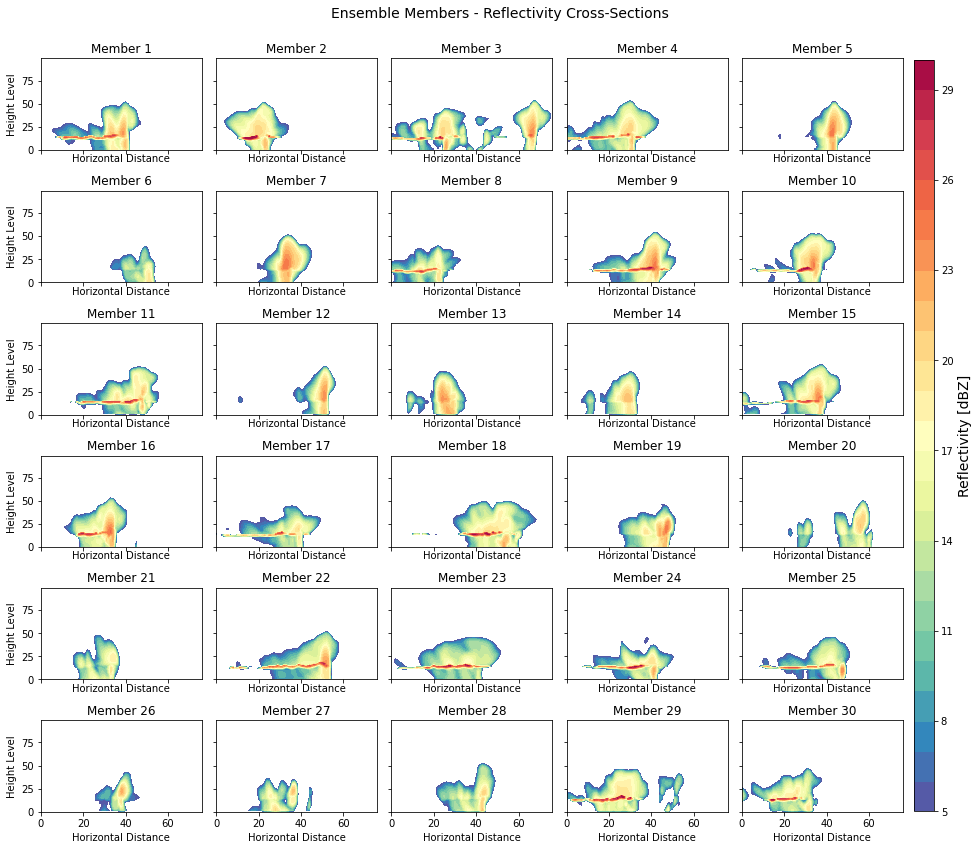

In [14]:
fig, axs = plt.subplots(6, 5, figsize=(14, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(nbv):
    ax = axs[i]
    label = f"Member {i+1}"

    levels = np.arange(5.,31.,1.)

 
    #cm = ax.pcolormesh(dbz_data_all[:, :, i].T, cmap="Spectral_r")
    cm = ax.contourf(dbz_data_all[:, :, i].T, cmap="Spectral_r", levels=levels)
    ax.set_title(label)
    ax.set_xlabel("Horizontal Distance")
    if i % 5 == 0:
        ax.set_ylabel("Height Level")

cbar_axis = fig.add_axes([0.91, 0.049, 0.02, 0.87])  # [left, bottom, width, height]
cbar = fig.colorbar(cm, cax=cbar_axis, orientation="vertical", label="Reflectivity [dBZ]")
cbar.set_label("Reflectivity [dBZ]", fontsize=14)
plt.suptitle("Ensemble Members - Reflectivity Cross-Sections", fontsize=14)

plt.tight_layout(rect=[0, 0, 0.91, 0.98])
plt.show()


In [11]:
np.nanmin(dbz_data_all[:,:,0])

-20.0